# Predicted TX spectrum

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import tx_model as tx
from tx_model import (FS_DAC, F_NCO, F_CARRIER, COMPARE_RATES, LFSR_TAPS,
                      mseq, rrc_taps, periodic_baseband, occupied_bw,
                      h_nrz, h_mix, board_loss_db, cw_ideal_dbm,
                      dac_output_lines, analyzer_trace, simulate, image_power,
                      plot_full_span, plot_chip_rate_compare, plot_fine_comb, print_summary)

Defining my usual plot appearance settings

In [4]:
plt.rcParams['font.size'] = '20';plt.rcParams['font.style'] = 'normal'
plt.rcParams['font.weight'] = 'normal';plt.rcParams['axes.grid'] = True;plt.rcParams['grid.linestyle'] = '-';
plt.rcParams['grid.linewidth'] = 0.4;plt.rcParams['grid.color'] = "Black";plt.rcParams['grid.alpha'] = 1;
plt.rcParams['lines.linewidth'] = 3;#plt.rcParams['axes.autolimit_mode'] = 'round_numbers';plt.rcParams['axes.axisbelow'] = True
plt.rcParams['xtick.direction'] = 'in';plt.rcParams['ytick.direction'] = 'in';plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 0.5;plt.rcParams['ytick.major.width'] = 1;plt.rcParams['ytick.minor.width'] = 0.5;
plt.rcParams['xtick.major.size'] = 4;plt.rcParams['xtick.minor.size'] = 2;plt.rcParams['ytick.major.size'] = 4;
plt.rcParams['ytick.minor.size'] = 2; plt.rcParams['svg.fonttype'] = 'none'; #cs = list(mcolors.TABLEAU_COLORS.values())
plt.rcParams['axes.linewidth']=1;plt.rcParams['xtick.top'] = True;plt.rcParams['ytick.right'] = True;
plt.rcParams['axes.spines.top'] = True;plt.rcParams['axes.spines.bottom'] = True;plt.rcParams['axes.spines.left'] = True;
plt.rcParams['axes.spines.right'] = True# Plot Appearance Settings

# FPGA Side

### 1. Linear Feedback Shift Register

In this cell, I simply call the mseq function, which runs the standard LFSR procedure to generate random number with a period of 2^n-1 for a n-bit register. In this case I am using 10 bits.

The register runs deterministically from there onwards based on a choice of two "taps" and an initial state (which I just set as an array of all 1s). These are whole numbers who represent the indices of the bits that will be XOR'd at each iteration.

That is all up to here.

length: 1023, ones: 512, zeros: 511, difference: 1


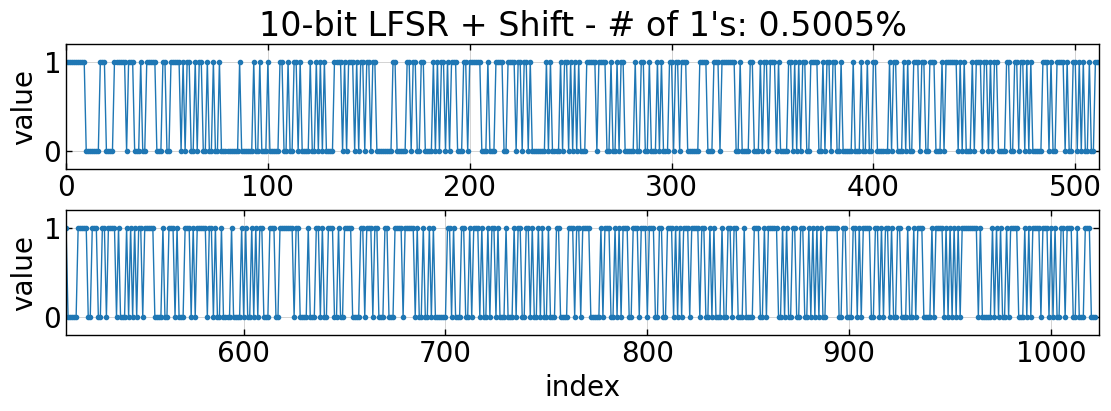

In [17]:
seq = mseq(10)
n_ones = int(np.count_nonzero(seq == 1))
n_zeros = int(np.count_nonzero(seq == 0))
print(f"length: {seq.size}, ones: {n_ones}, zeros: {n_zeros}, difference: {n_ones - n_zeros}")


fig, ax = plt.subplots(2, 1,figsize=(11, 4), layout = 'constrained')
ax[0].plot(seq, marker='o', ms=3, lw=1)
ax[0].set(ylabel="value",
       title=f"10-bit LFSR + Shift - # of 1's: {n_ones/(n_ones+n_zeros):.4f}%",
       xlim=(0, 512), ylim=(-0.2, 1.2))
ax[0].grid(alpha=0.3)
ax[1].plot(seq, marker='o', ms=3, lw=1)
ax[1].set(ylabel="value", xlabel='index',
       xlim=(512, 1024), ylim=(-0.2, 1.2))
ax[1].grid(alpha=0.3)

### 2. BPSK and Root-Raised-Cosine (RRC) Pulse Shaping

#### 2a. BPSK mapping and upsampling

* In this cell, I call on the same LFSR function as before (since it's deterministic, the output will be the same for the same choice of taps.)
* This array ("seq") is then shifted to turn 1->-1 and 0->1. The shifted array is called "up"
* "Up" is then turned into a new "chips" array, which is upsampled by the SPS (samples per chips)

Note that the chip rate $f_c$ relates to the DAC sampling rate $f_s$ (4.9152 GS/s) by:
$$
f_c=\frac{f_s}{N_s}
$$
So a specific choice of $N_s$ (number of samples per chips) will determine how many DAC sample periods to hold the current chip for before the next chip comes long. In the code I refere to this $N_S$ as SPS_DAC.

* Nevertheless, it makes sense to talk about a SPS_FGPA that is high enough to completely determine the frequencies in the signal $(f_{samp}> 2*f_{max})$ without unnecessarily adding computational cost.
* Although it can be chosen arbitrarily, from the start I assumed that a SPS_DAC of 96 would be reasonable, in that it will give a chip rate 51.2Mcps = 4.9152/96. This final effective chip rate will set the bandwidth of the resulting signal after the RRC filter to $(1+\beta)\times$ CHIP_RATE (69MHz if $\beta=0.35$). At this rate, the bandwidth is likely to fit completely within the amateur band of 5.725-5.850 GHz amateur band.
* Then I set SPS_FPGA to 8, which means the interpolation will add a factor of 12 in the sampling rate later. This is an integer fraction that is compatible with the RFSoC's operation.

But note that the CHIP_RATE is always the same. The Samples/Chip changes between stages and the effective Sample Rate changes correspondingly:

| Stage | Sample rate | Samples/chip | Chip rate = sample rate / samples per chip |
|---|---:|---:|---:|
| FPGA (pre-×12) | FS_DAC / 12 = 409.6 MS/s | 8 | 409.6 / 8 = **51.2 Mcps** |
| DAC (post-×12) | FS_DAC = 4915.2 MS/s | 96 | 4915.2 / 96 = **51.2 Mcps** |


So our signal will behave something like this:

* In the very beggining, the chips are one sample per chip, so sampling rate is 51.2 Mcps (design choice) $\rightarrow$ flat spectrum across $\pm$51.2/2=25.6 MHz.
* Upsample by zero-stuffing, raising the sample/chip rate from 1 to 8. Spectrum now extends to 8x $\pm$ 25.6MHz = $\pm$ 204.8. The extended space is filled by copies of the original spectrum every 51.2 MHz.
* To carry 51.2M chips per second, the smalles frequency you need is 25.6 MHz (Nyquist bandwidth)
* A brick-wall filter at 25.6MHz ($\beta$=0) could do the job. Instead the RRC filter avoids the sharp cut and, with a $\beta=0.35$ value, leads to a bandwidth of $(1+0.35)\times 51.2/2 = 35.6MHz$.
* So before the NCO, the signal has a bandwidth of about 35.6MHz centered on zero, represented by a sample rate of 409.6 MS/s at a Chip Rate of 51.2 Mcps.
* After the NCO (digital mixer), each sample is multiplied by a sample (at the DAC rate) of a 784.8 MHz cosine, as in
$$
y_{NCO}[n]=b[n]\times\cos\left(2\pi \times \frac{784.8 \text{MHz}}{4915.2 \text{MHz}} \times n\right)
$$

* After this step, the signal is now centered at 784.8 MHz. This is a frequency I choose for the NCO at the Jupyter notebook interface of the RFSoC.
* Just like before, any sampled signal at frequency f also has copies at every $k \times fs \pm f$. When the DAC turns the samples into an analog voltage, all of those copies are physically present at its output.

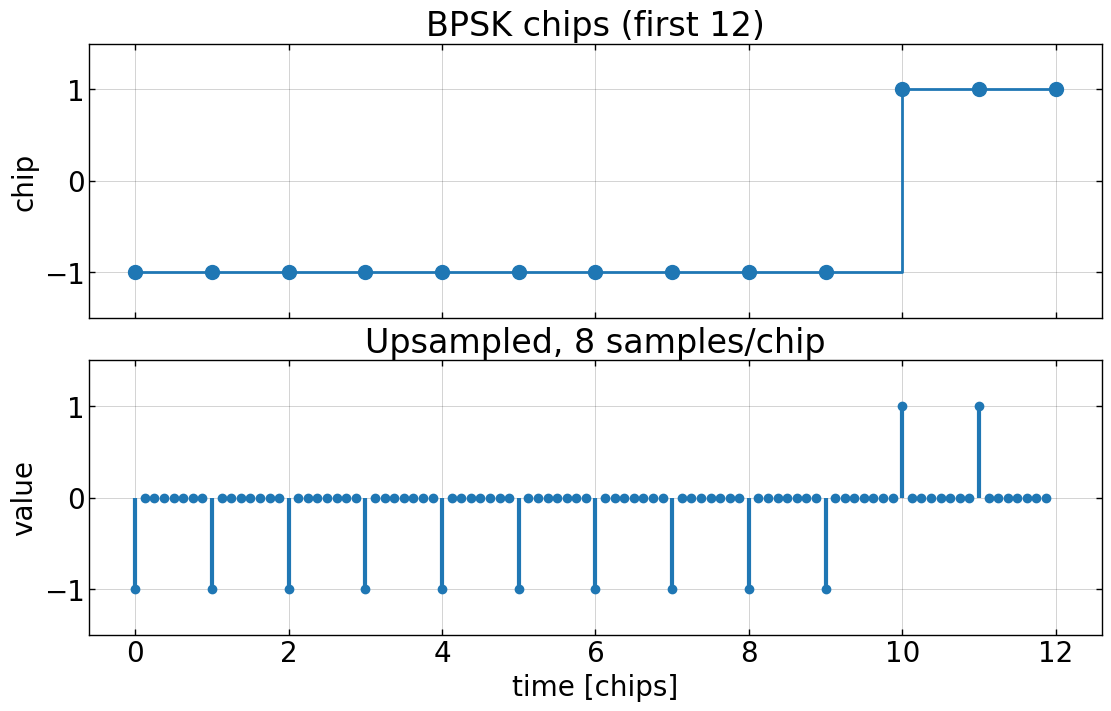

In [ ]:
# Sampling rates
NBITS     = 10             # LFSR length; PRN period = 2^NBITS - 1 chips
SPS_DAC = 96
CHIP_RATE = FS_DAC / SPS_DAC    # chips/s (51.2 Mcps)
SPS_FPGA  = 8       # samples per chip
INTERP = SPS_DAC / SPS_FPGA



BETA      = 0.35           # RRC roll-off
PEAK_AMP  = 0.5            # waveform peak, same scale as DAC gain (0.5 = bench tone)
SPAN = 16     # RRC filter length in chips
N_SHOW = 12    # chips shown in the time-domain plots

fs_FPGA = SPS_FPGA * CHIP_RATE     # baseband sample rate
seq = mseq(NBITS)

chips = 1.0 - 2.0 * seq                   # 0 -> +1, 1 -> -1
up = np.zeros(chips.size * SPS_FPGA)
up[::SPS] = chips                         # one chip every SPS samples, zeros between
n = np.arange(N_SHOW * SPS_FPGA)               # sample indices shown

fig, ax = plt.subplots(2, 1, figsize=(11, 7), layout='constrained', sharex=True)
ax[0].step(np.arange(N_SHOW + 1), np.append(chips[:N_SHOW], chips[N_SHOW - 1]), where="post", lw=2, ms=10, marker='o')
ax[0].set(ylabel="chip", title=f"BPSK chips (first {N_SHOW})", ylim=(-1.5, 1.5))
ax[0].grid(alpha=0.3)
ax[1].stem(n / SPS, up[:N_SHOW * SPS], basefmt=" ")
ax[1].set(ylabel="value", xlabel="time [chips]", title=f"Upsampled, {SPS} samples/chip", ylim=(-1.5, 1.5))
ax[1].grid(alpha=0.3)

#### 2b. The RRC filter

Top: impulse response (it does *not* cross zero at every chip, only RRC × RRC does).
Bottom: frequency response. Dotted lines at (1−β)Rc/2, Rc/2, (1+β)Rc/2: flat below the first, −6 dB (RC) at the middle, zero beyond the last.

band edges [MHz]: [16.64, 25.6, 34.56]


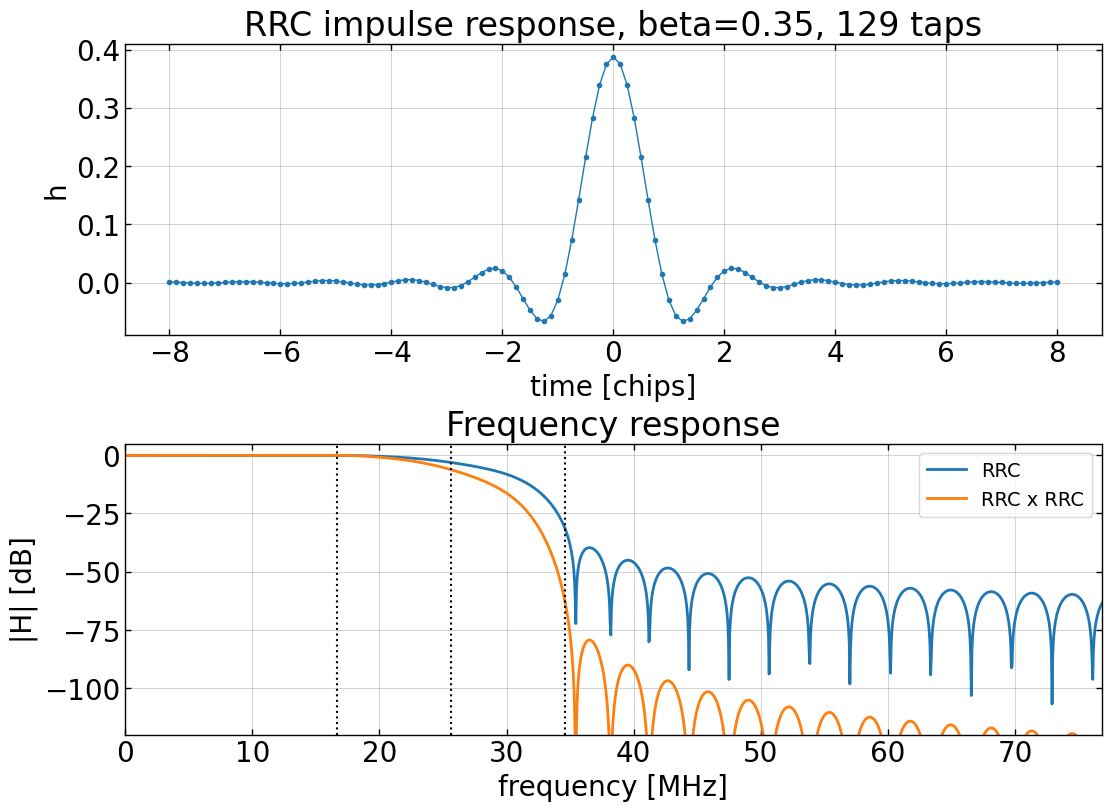

In [39]:
h = rrc_taps(BETA, SPS, SPAN)
th = (np.arange(h.size) - h.size // 2) / SPS          # time in chips, centered on 0

NFFT = 8192
f = np.fft.fftshift(np.fft.fftfreq(NFFT, 1 / fs_bb)) #the shift here is just reordering for display, otherwise numpy will put the negative frequencies at the end.
H = np.fft.fftshift(np.abs(np.fft.fft(h, NFFT)))
H /= H.max()
edges = [(1 - BETA) * CHIP_RATE / 2, CHIP_RATE / 2, (1 + BETA) * CHIP_RATE / 2]
print("band edges [MHz]:", [round(e / 1e6, 2) for e in edges])

fig, ax = plt.subplots(2, 1, figsize=(11, 8), layout='constrained')
ax[0].plot(th, h, marker='o', ms=3, lw=1)
ax[0].set(xlabel="time [chips]", ylabel="h", title=f"RRC impulse response, beta={BETA}, {h.size} taps")
ax[0].grid(alpha=0.3)
ax[1].plot(f / 1e6, 20 * np.log10(H + 1e-12), lw=2, label="RRC")
ax[1].plot(f / 1e6, 20 * np.log10(H ** 2 + 1e-12), lw=2, label="RRC x RRC")
for e in edges:
    ax[1].axvline(e / 1e6, color="k", ls=":", lw=1.5)
ax[1].set(xlabel="frequency [MHz]", ylabel="|H| [dB]", title="Frequency response",
          xlim=(0, 1.5 * CHIP_RATE / 1e6), ylim=(-120, 5))
ax[1].legend(fontsize=14); ax[1].grid(alpha=0.3)

#### 2c. Filtering the chips

Circular convolution, because the PRN repeats with no gaps. The filter delays the signal by half its length; that is undone so the pulses line up with the chips.
Top: at the chip instants (dots) the values wander around ±0.3. That is ISI from the TX filter alone.
Bottom: spectrum before (flat impulses) and after (confined to ±Rc(1+β)/2).

occupied BW ~ Rc(1+beta) = 69.1 MHz
matches periodic_baseband: True


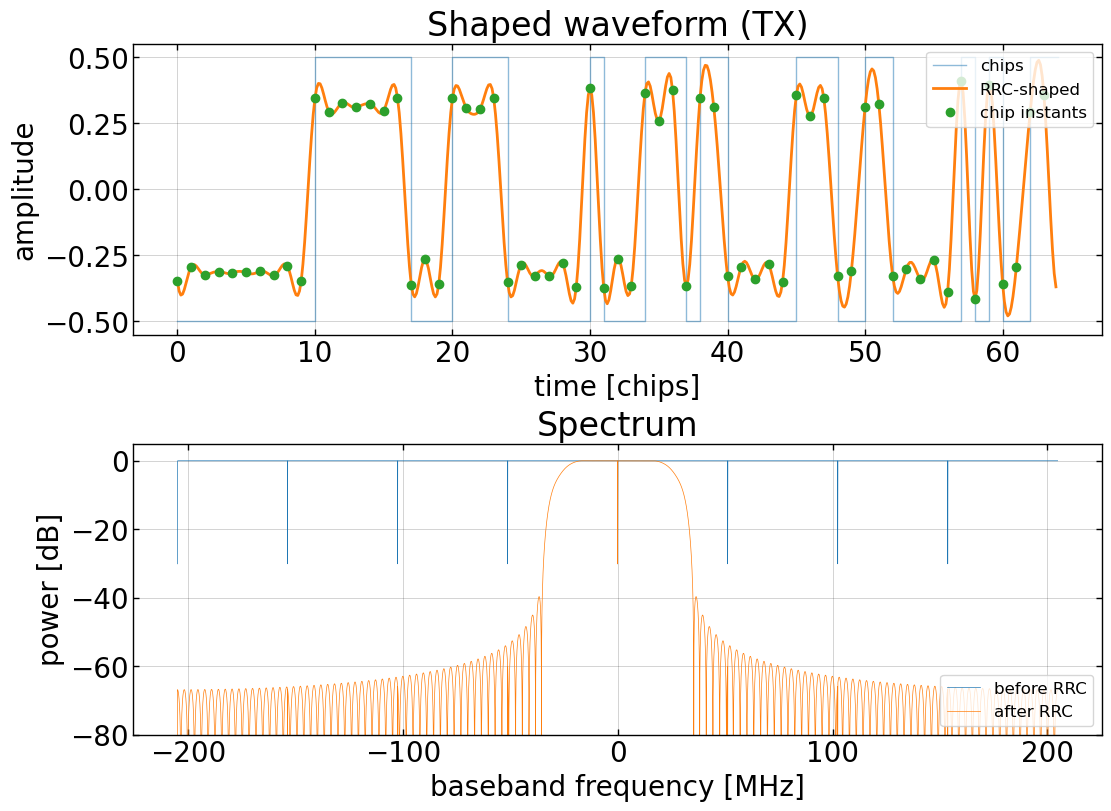

In [40]:
shaped = np.real(np.fft.ifft(np.fft.fft(up) * np.fft.fft(h, up.size)))
delay = h.size // 2                                   # filter delay in samples (half the taps)
shaped = np.roll(shaped, -delay)                      # undo the delay so chips line up
shaped *= PEAK_AMP / np.max(np.abs(shaped))           # same peak scaling as periodic_baseband

Pu = np.fft.fftshift(np.abs(np.fft.fft(up)) ** 2)
Ps = np.fft.fftshift(np.abs(np.fft.fft(shaped)) ** 2)
fu = np.fft.fftshift(np.fft.fftfreq(up.size, 1 / fs_bb))
print(f"occupied BW ~ Rc(1+beta) = {CHIP_RATE * (1 + BETA) / 1e6:.1f} MHz")

fig, ax = plt.subplots(2, 1, figsize=(11, 8), layout='constrained')
ax[0].step(np.arange(N_SHOW + 1), PEAK_AMP * np.append(chips[:N_SHOW], chips[N_SHOW - 1]),
           where="post", lw=1, alpha=0.5, label="chips")
ax[0].plot(n / SPS, shaped[:N_SHOW * SPS], lw=2, label="RRC-shaped")
ax[0].plot(n[::SPS] / SPS, shaped[:N_SHOW * SPS:SPS], 'o', ms=6, label="chip instants")
ax[0].set(xlabel="time [chips]", ylabel="amplitude", title="Shaped waveform (TX)")
ax[0].legend(fontsize=12, loc="upper right"); ax[0].grid(alpha=0.3)
ax[1].plot(fu / 1e6, 10 * np.log10(Pu / Pu.max() + 1e-15), lw=0.5, label="before RRC")
ax[1].plot(fu / 1e6, 10 * np.log10(Ps / Ps.max() + 1e-15), lw=0.5, label="after RRC")
ax[1].set(xlabel="baseband frequency [MHz]", ylabel="power [dB]", title="Spectrum", ylim=(-80, 5))
ax[1].legend(fontsize=12, loc="lower right"); ax[1].grid(alpha=0.3)

# check: same waveform as periodic_baseband(), up to the filter delay
b, _, _ = periodic_baseband(CHIP_RATE, BETA, nbits=NBITS, sps=SPS, span=SPAN, peak_amp=PEAK_AMP)
print("matches periodic_baseband:", np.allclose(np.roll(b, -delay), shaped))

#### 2d. Eye diagrams: why RRC on both ends

Overlay 2-chip slices centered on each chip instant. After the TX RRC alone the eye is blurred (ISI).
After the RX matched RRC (RRC × RRC = raised cosine) every trace passes through ±1 at the chip instant: zero ISI.
The small leftover spread comes from truncating the filter to `SPAN` chips.

spread at chip instants: TX 0.666, RX 0.013


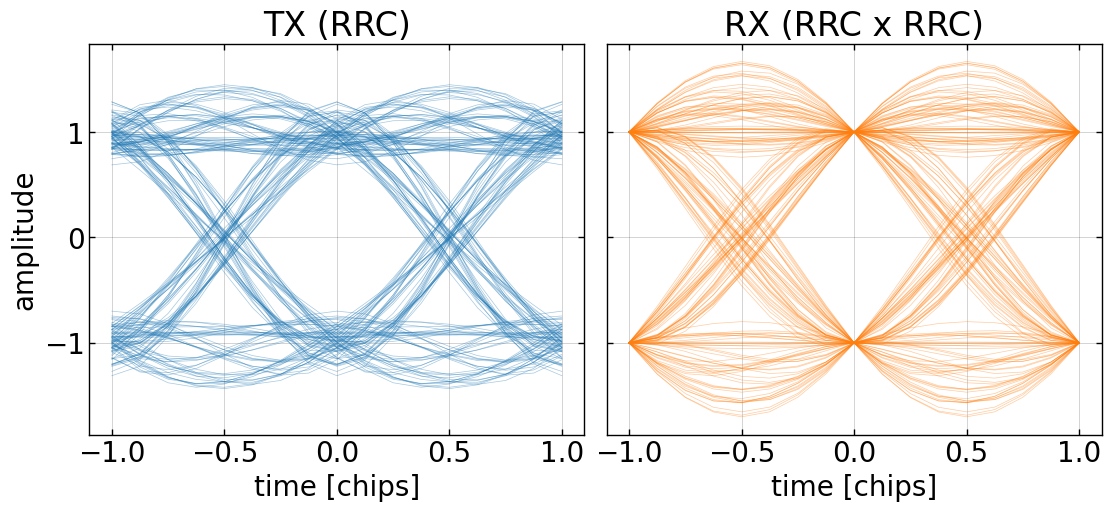

In [9]:
rx = np.real(np.fft.ifft(np.fft.fft(shaped) * np.fft.fft(h, shaped.size)))
rx = np.roll(rx, -delay)                              # undo the second filter delay
rx /= np.mean(np.abs(rx[::SPS]))                      # normalize: chip instants at +/-1
tx_n = shaped / np.mean(np.abs(shaped[::SPS]))
print(f"spread at chip instants: TX {np.ptp(np.abs(tx_n[::SPS])):.3f}, RX {np.ptp(np.abs(rx[::SPS])):.3f}")

te = np.arange(-SPS, SPS + 1) / SPS                   # 2 chips wide, centered on a chip instant
fig, ax = plt.subplots(1, 2, figsize=(11, 5), layout='constrained', sharey=True)
for k in range(2, 200):
    i = k * SPS
    ax[0].plot(te, tx_n[i - SPS:i + SPS + 1], "C0", lw=0.5, alpha=0.4)
    ax[1].plot(te, rx[i - SPS:i + SPS + 1], "C1", lw=0.5, alpha=0.4)
ax[0].set(xlabel="time [chips]", ylabel="amplitude", title="TX (RRC)")
ax[1].set(xlabel="time [chips]", title="RX (RRC x RRC)")
for a in ax:
    a.grid(alpha=0.3)

# DAC Side